# Linear Models: a visual, executable learning path

**Flow:** data → fit → diagnose → regularize → classify → practice. Every figure below is generated by the cell immediately before it.

## 1. Setup
We use deterministic synthetic data so you can change one parameter at a time and see the effect.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, confusion_matrix
rng = np.random.default_rng(7)

## 2. Ordinary least squares (OLS)
OLS chooses the line that minimizes the **sum of squared vertical residuals**. The gray segments are residuals: actual minus prediction.

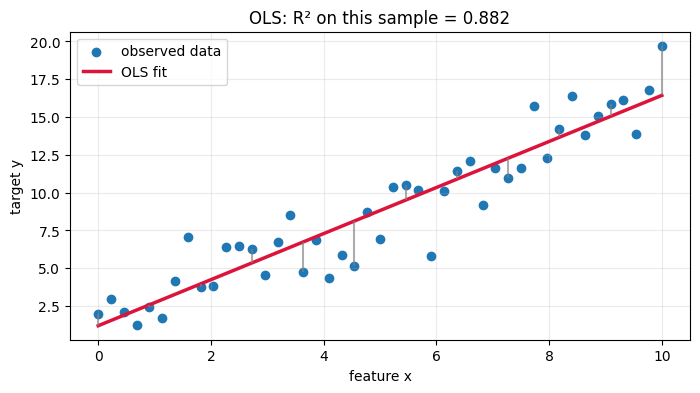

In [2]:
x = np.linspace(0, 10, 45)
y = 2 + 1.5*x + rng.normal(0, 2, len(x))
ols = LinearRegression().fit(x[:, None], y)
pred = ols.predict(x[:, None])
plt.figure(figsize=(8,4))
plt.scatter(x, y, label='observed data')
plt.plot(x, pred, c='crimson', lw=2.5, label='OLS fit')
for xi, yi, pi in zip(x[::4], y[::4], pred[::4]): plt.vlines(xi, min(yi,pi), max(yi,pi), color='gray', alpha=.65)
plt.title(f'OLS: R² on this sample = {r2_score(y,pred):.3f}')
plt.xlabel('feature x'); plt.ylabel('target y'); plt.legend(); plt.grid(alpha=.25); plt.show()

## 3. Generalization and residual checks
A small training error is not enough. Evaluate on held-out data. Residuals should not show a curved pattern or widening spread.

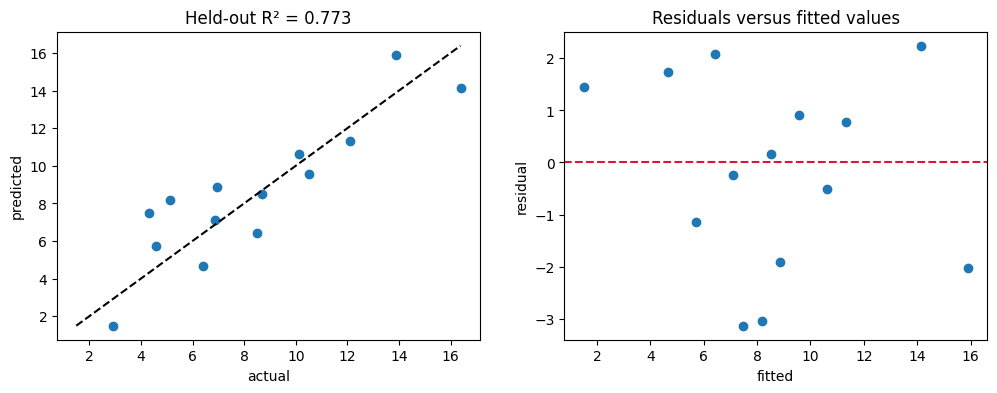

In [3]:
x_train, x_test, y_train, y_test = train_test_split(x[:,None], y, test_size=.3, random_state=7)
model = LinearRegression().fit(x_train, y_train)
test_pred = model.predict(x_test)
residuals = y_test - test_pred
fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].scatter(y_test, test_pred); lim=[min(y_test.min(),test_pred.min()), max(y_test.max(),test_pred.max())]; ax[0].plot(lim,lim,'k--'); ax[0].set(title=f'Held-out R² = {r2_score(y_test,test_pred):.3f}',xlabel='actual',ylabel='predicted')
ax[1].scatter(test_pred,residuals); ax[1].axhline(0,color='crimson',ls='--'); ax[1].set(title='Residuals versus fitted values',xlabel='fitted',ylabel='residual')
plt.show()

## 4. Why regularization?
With many correlated or noisy features, OLS can overfit. Ridge (L2) shrinks all coefficients; Lasso (L1) can set some coefficients exactly to zero. Scaling belongs **inside a Pipeline** so the scaler is fit only on training rows.

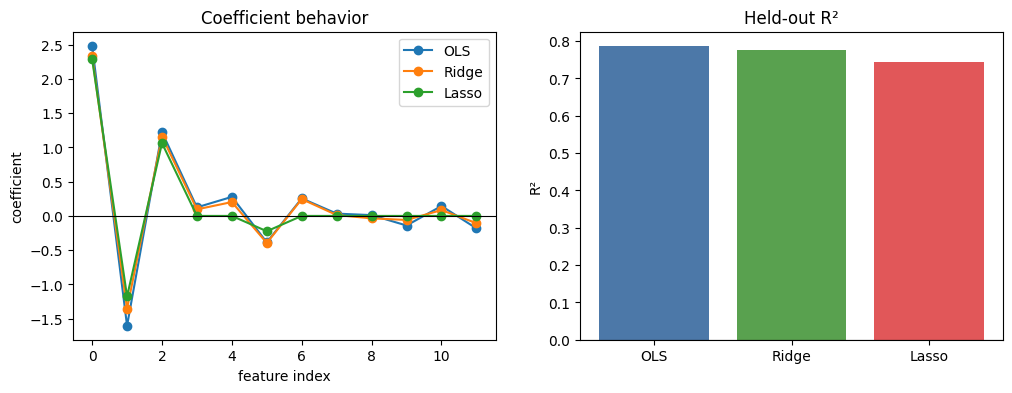

In [4]:
X = rng.normal(size=(120, 12)); truth=np.array([2.5,-2,1.5,0,0,0,0,0,0,0,0,0]); target=X@truth+rng.normal(0,2,120)
Xt,Xv,yt,yv=train_test_split(X,target,test_size=.3,random_state=7)
models={'OLS':LinearRegression(), 'Ridge':Pipeline([('scale',StandardScaler()),('model',Ridge(alpha=8))]), 'Lasso':Pipeline([('scale',StandardScaler()),('model',Lasso(alpha=.25))])}
fig, ax=plt.subplots(1,2,figsize=(12,4)); scores=[]
for name,m in models.items():
    m.fit(Xt,yt); scores.append(r2_score(yv,m.predict(Xv))); coef=m.coef_ if name=='OLS' else m.named_steps['model'].coef_; ax[0].plot(coef,'o-',label=name)
ax[0].axhline(0,color='k',lw=.8); ax[0].set(title='Coefficient behavior',xlabel='feature index',ylabel='coefficient'); ax[0].legend()
ax[1].bar(models.keys(),scores,color=['#4c78a8','#59a14f','#e15759']); ax[1].axhline(0,color='k',lw=.8); ax[1].set(title='Held-out R²',ylabel='R²')
plt.show()

## 5. Logistic regression
Logistic regression first estimates a probability between 0 and 1 using the sigmoid function. A class label comes only after choosing a threshold, commonly 0.5.

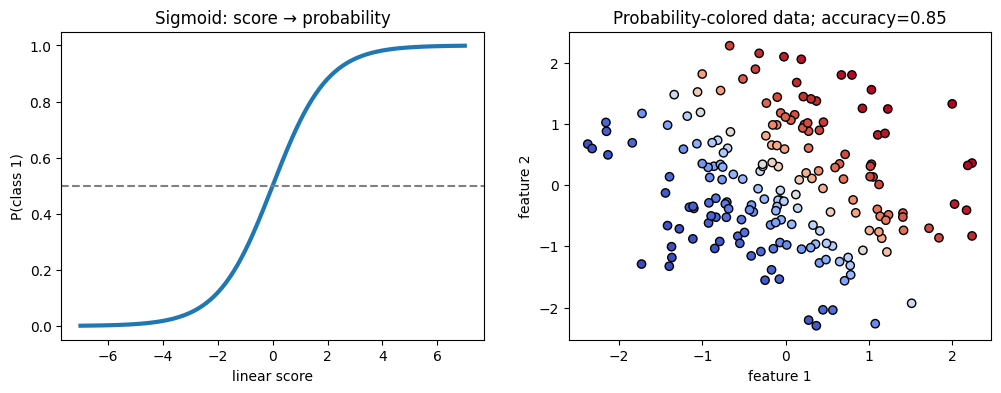

In [5]:
z=np.linspace(-7,7,300); sigmoid=1/(1+np.exp(-z))
Xc=rng.normal(size=(180,2)); yc=(Xc[:,0]+.8*Xc[:,1]+rng.normal(0,.65,180)>0).astype(int)
clf=Pipeline([('scale',StandardScaler()),('model',LogisticRegression())]).fit(Xc,yc)
prob=clf.predict_proba(Xc)[:,1]; label=(prob>=.5).astype(int)
fig,ax=plt.subplots(1,2,figsize=(12,4)); ax[0].plot(z,sigmoid,lw=3); ax[0].axhline(.5,color='gray',ls='--'); ax[0].set(title='Sigmoid: score → probability',xlabel='linear score',ylabel='P(class 1)')
ax[1].scatter(Xc[:,0],Xc[:,1],c=prob,cmap='coolwarm',edgecolor='black'); ax[1].set(title=f'Probability-colored data; accuracy={(label==yc).mean():.2f}',xlabel='feature 1',ylabel='feature 2')
plt.show()

## 6. Practical checklist
1. Define the target and metric. 2. Split before learning preprocessing. 3. Fit a simple baseline. 4. Diagnose residuals and feature scale. 5. Use cross-validation for regularization strength. 6. Report held-out performance and limitations.

**Key caution:** A model predicts associations. It does not by itself establish causation.